In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

Pandas: 3.0.5
NumPy: 2.5.2
Matplotlib: 3.11.1


# Global Happiness Analytics

## Task 1 — Load & Validate

In this task, the World Happiness Report 2019 dataset is loaded and checked for missing values and duplicate country records.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("2019.csv")

print("Dataset shape:", df.shape)

df.head()

In [3]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\vidit\OneDrive\Desktop\Data-Science-Internship
['.git', '.gitmodules', '.venv', '.venv-1', '.venv-2', 'Global_Happiness_Analytics.ipynb', 'README.md', 'Week 1 - FirstProject', 'Week 1.1 - Python_Data_Science_Assignment', 'Week 1.2 - Student-Academic-Analytics', 'Week 2', 'Week 2 - Data_Visualization_Matplotlib', 'Week 2 Project']


In [6]:
df = pd.read_csv(
    r"C:\Users\vidit\OneDrive\Desktop\Data-Science-Internship\Week 2 Project\2019.csv"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (156, 9)


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    str    
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 11.1 KB


In [8]:
df = df.rename(columns={
    "Overall rank": "overall_rank",
    "Country or region": "country",
    "Score": "happiness_score",
    "GDP per capita": "gdp_per_capita",
    "Social support": "social_support",
    "Healthy life expectancy": "healthy_life_expectancy",
    "Freedom to make life choices": "freedom",
    "Generosity": "generosity",
    "Perceptions of corruption": "corruption_perception"
})

df.head()

,overall_rank,country,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [9]:
print(df.columns.tolist())

['overall_rank', 'country', 'happiness_score', 'gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom', 'generosity', 'corruption_perception']


In [10]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
overall_rank               0
country                    0
happiness_score            0
gdp_per_capita             0
social_support             0
healthy_life_expectancy    0
freedom                    0
generosity                 0
corruption_perception      0
dtype: int64


In [12]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [13]:
print("Duplicate country rows:", df["country"].duplicated().sum())

Duplicate country rows: 0


In [14]:
df[df["country"].duplicated(keep=False)]

,overall_rank,country,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception


The dataset was checked for missing values and duplicate country records before analysis.

## Task 2 — Statistical Summaries

This section calculates descriptive statistics for all numeric variables and checks their distributions for potential skewness.

In [15]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['overall_rank', 'happiness_score', 'gdp_per_capita', 'social_support',
       'healthy_life_expectancy', 'freedom', 'generosity',
       'corruption_perception'],
      dtype='str')

In [16]:
summary = pd.DataFrame({
    "mean": df[numeric_columns].mean(),
    "median": df[numeric_columns].median(),
    "std_dev": df[numeric_columns].std()
})

summary

,mean,median,std_dev
overall_rank,78.500000,78.5000,45.177428
happiness_score,5.407096,5.3795,1.113120
gdp_per_capita,0.905147,0.9600,0.398389
social_support,1.208814,1.2715,0.299191
healthy_life_expectancy,0.725244,0.7890,0.242124
freedom,0.392571,0.4170,0.143289
generosity,0.184846,0.1775,0.095254
corruption_perception,0.110603,0.0855,0.094538


In [17]:
skewness = df[numeric_columns].skew().sort_values(ascending=False)

skewness

corruption_perception      1.650410
generosity                 0.745942
happiness_score            0.011450
overall_rank               0.000000
gdp_per_capita            -0.385232
healthy_life_expectancy   -0.613841
freedom                   -0.685636
social_support            -1.134728
dtype: float64

In [18]:
strongly_skewed = skewness[skewness.abs() > 1]

print("Strongly skewed columns:")
print(strongly_skewed)

Strongly skewed columns:
corruption_perception    1.650410
social_support          -1.134728
dtype: float64


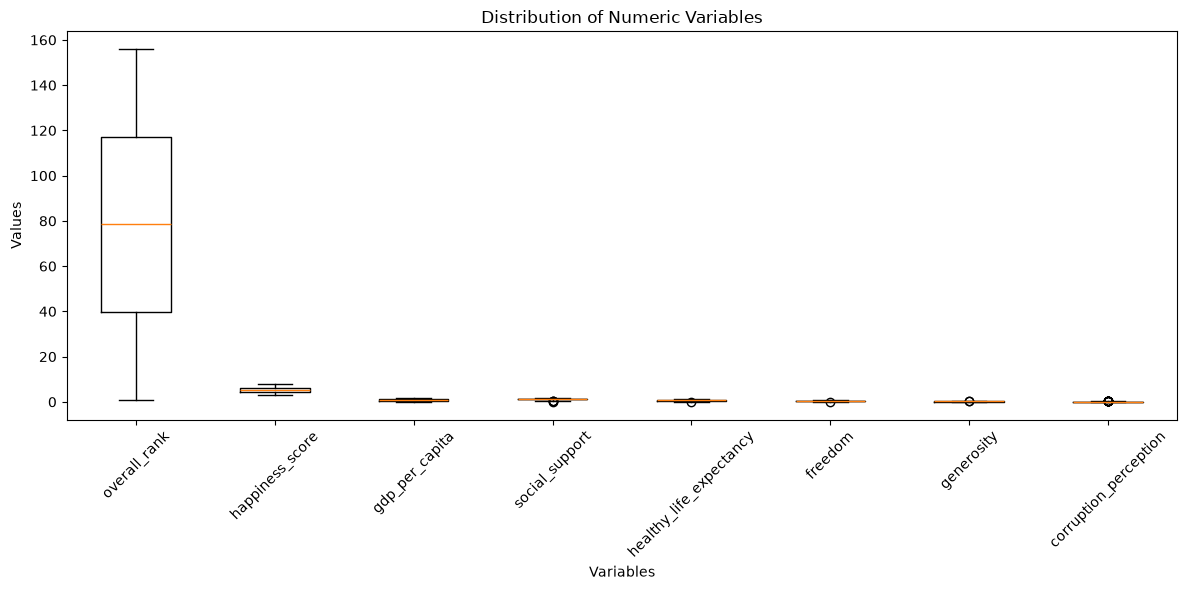

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

data = [df[column].dropna() for column in numeric_columns]

ax.boxplot(
    data,
    tick_labels=numeric_columns
)

ax.set_title("Distribution of Numeric Variables")
ax.set_xlabel("Variables")
ax.set_ylabel("Values")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 3 — Correlation Analysis

A correlation matrix is used to understand the relationships between the numerical variables in the dataset.

In [21]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,overall_rank,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception
overall_rank,1.000000,-0.989096,-0.801947,-0.767465,-0.787411,-0.546606,-0.047993,-0.351959
happiness_score,-0.989096,1.000000,0.793883,0.777058,0.779883,0.566742,0.075824,0.385613
gdp_per_capita,-0.801947,0.793883,1.000000,0.754906,0.835462,0.379079,-0.079662,0.298920
social_support,-0.767465,0.777058,0.754906,1.000000,0.719009,0.447333,-0.048126,0.181899
healthy_life_expectancy,-0.787411,0.779883,0.835462,0.719009,1.000000,0.390395,-0.029511,0.295283
freedom,-0.546606,0.566742,0.379079,0.447333,0.390395,1.000000,0.269742,0.438843
generosity,-0.047993,0.075824,-0.079662,-0.048126,-0.029511,0.269742,1.000000,0.326538
corruption_perception,-0.351959,0.385613,0.298920,0.181899,0.295283,0.438843,0.326538,1.000000


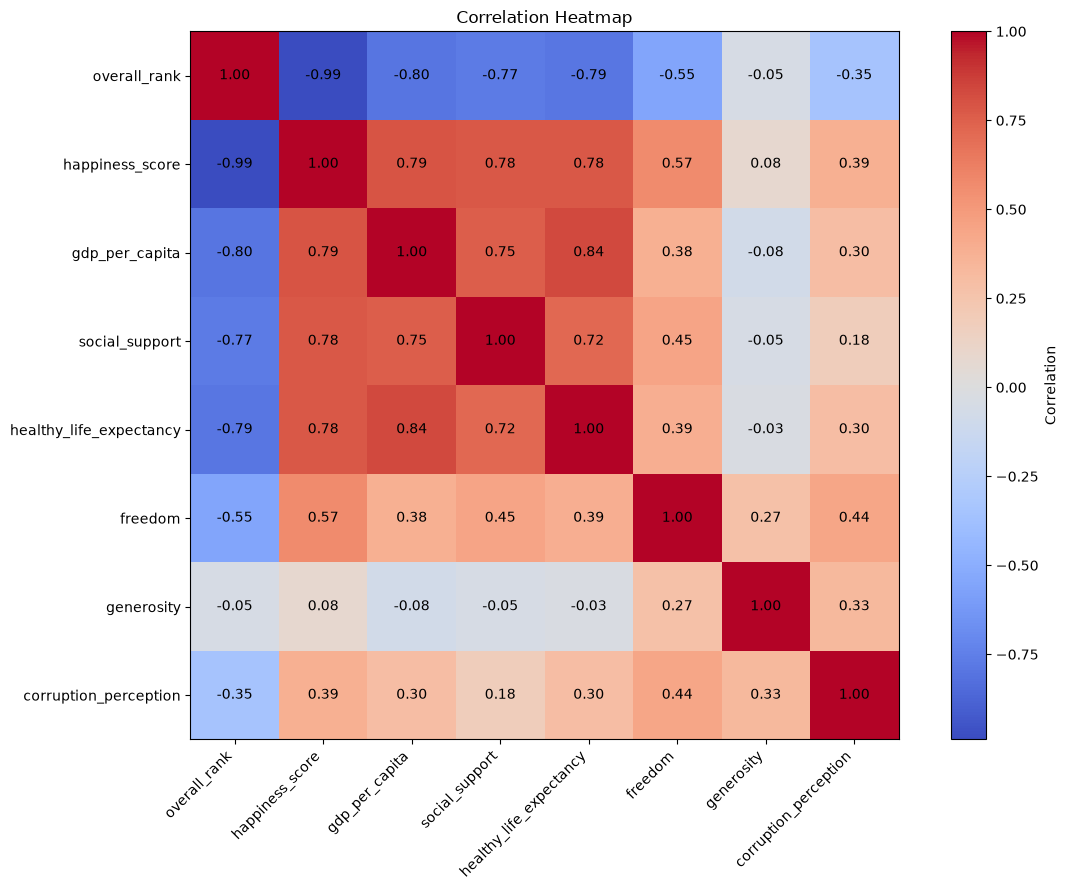

In [22]:
fig, ax = plt.subplots(figsize=(12, 9))

im = ax.imshow(correlation_matrix, cmap="coolwarm")

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.columns)

ax.set_title("Correlation Heatmap")

fig.colorbar(im, ax=ax, label="Correlation")

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 4 — Outlier Detection

The Interquartile Range (IQR) method is used to identify potential outliers in happiness score and GDP per capita.

In [24]:
def find_iqr_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, q1, q3, iqr, lower_bound, upper_bound

In [25]:
gdp_outliers, q1_g, q3_g, iqr_g, lower_g, upper_g = find_iqr_outliers(
    df,
    "gdp_per_capita"
)

print("GDP per Capita")
print("Q1:", q1_g)
print("Q3:", q3_g)
print("IQR:", iqr_g)
print("Lower Bound:", lower_g)
print("Upper Bound:", upper_g)

gdp_outliers[["country", "gdp_per_capita"]]

GDP per Capita
Q1: 0.60275
Q3: 1.2325000000000002
IQR: 0.6297500000000001
Lower Bound: -0.34187500000000026
Upper Bound: 2.177125


,country,gdp_per_capita


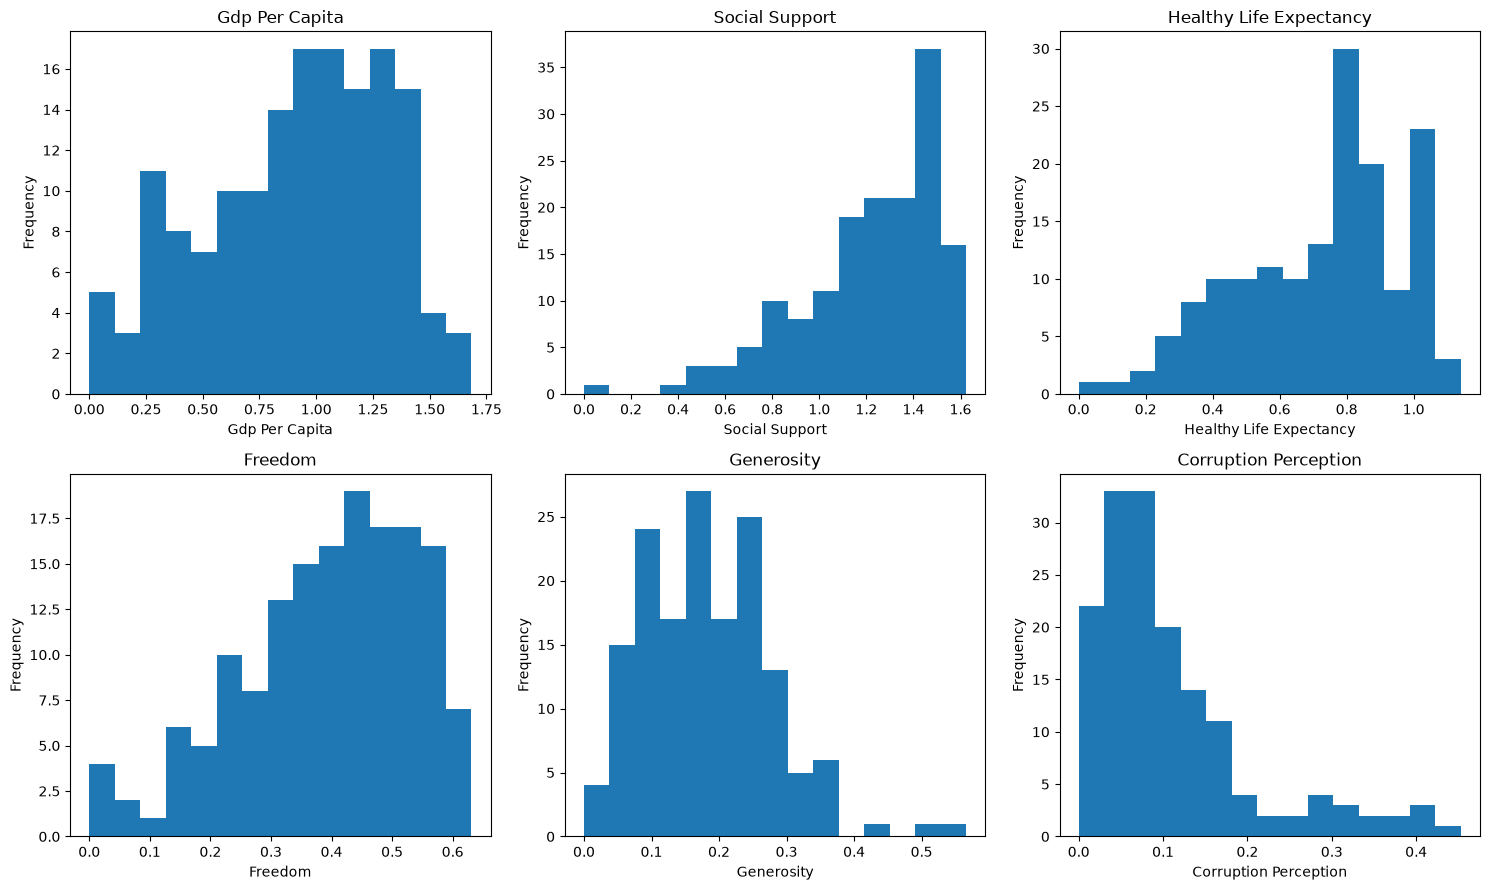

In [26]:
features = [
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "generosity",
    "corruption_perception"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, feature in zip(axes.flatten(), features):
    ax.hist(df[feature].dropna(), bins=15)
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel(feature.replace("_", " ").title())
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

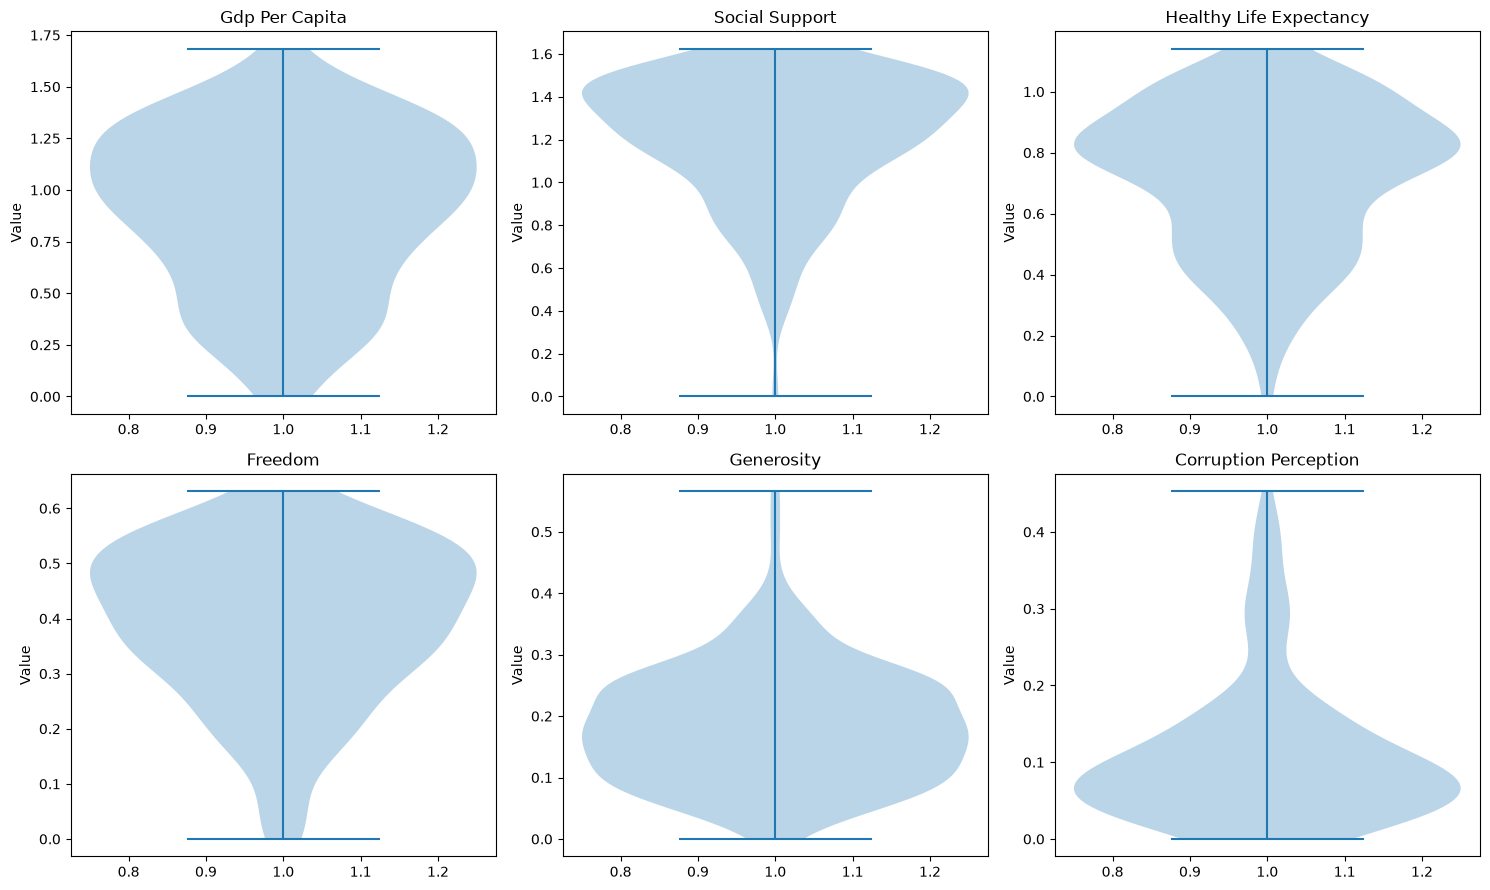

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, feature in zip(axes.flatten(), features):
    ax.violinplot(df[feature].dropna())
    ax.set_title(feature.replace("_", " ").title())
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

## Task 6 — Ranking View

The following chart compares the 10 happiest and 10 least happy countries according to the happiness score.

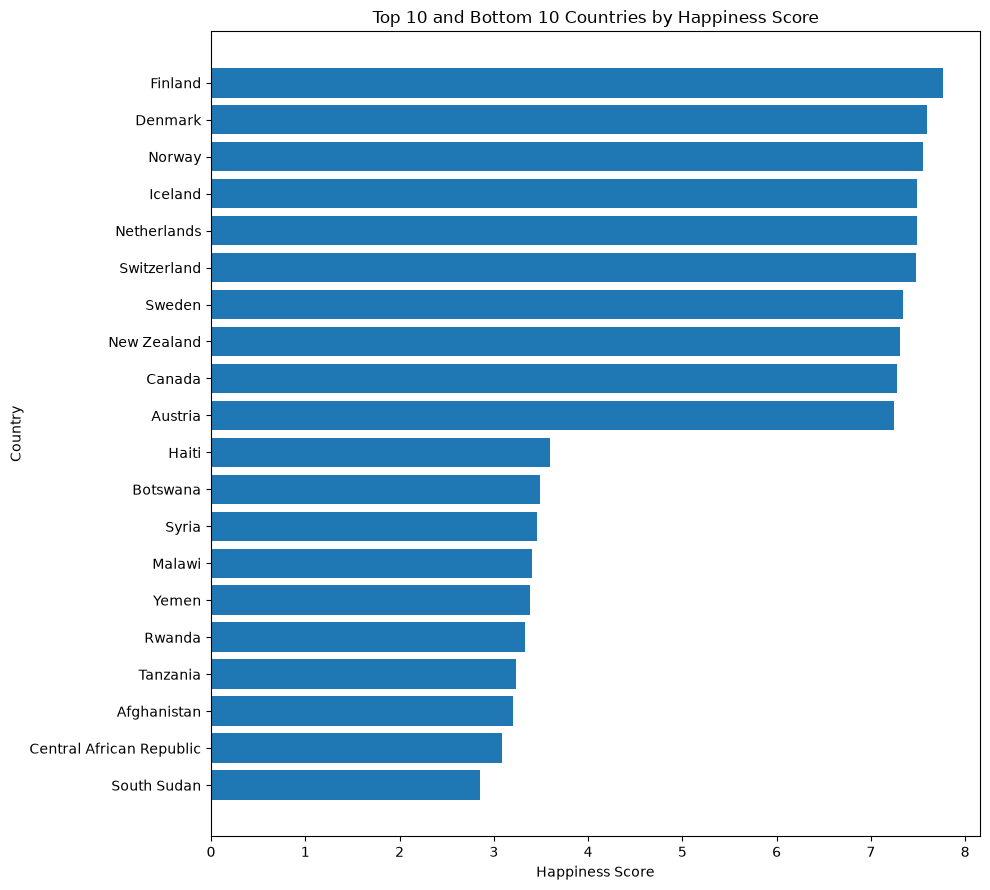

In [28]:
top_10 = df.nlargest(10, "happiness_score")

bottom_10 = df.nsmallest(10, "happiness_score")

ranking_df = pd.concat([top_10, bottom_10])

ranking_df = ranking_df.sort_values("happiness_score")

fig, ax = plt.subplots(figsize=(10, 9))

ax.barh(
    ranking_df["country"],
    ranking_df["happiness_score"]
)

ax.set_title("Top 10 and Bottom 10 Countries by Happiness Score")
ax.set_xlabel("Happiness Score")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()

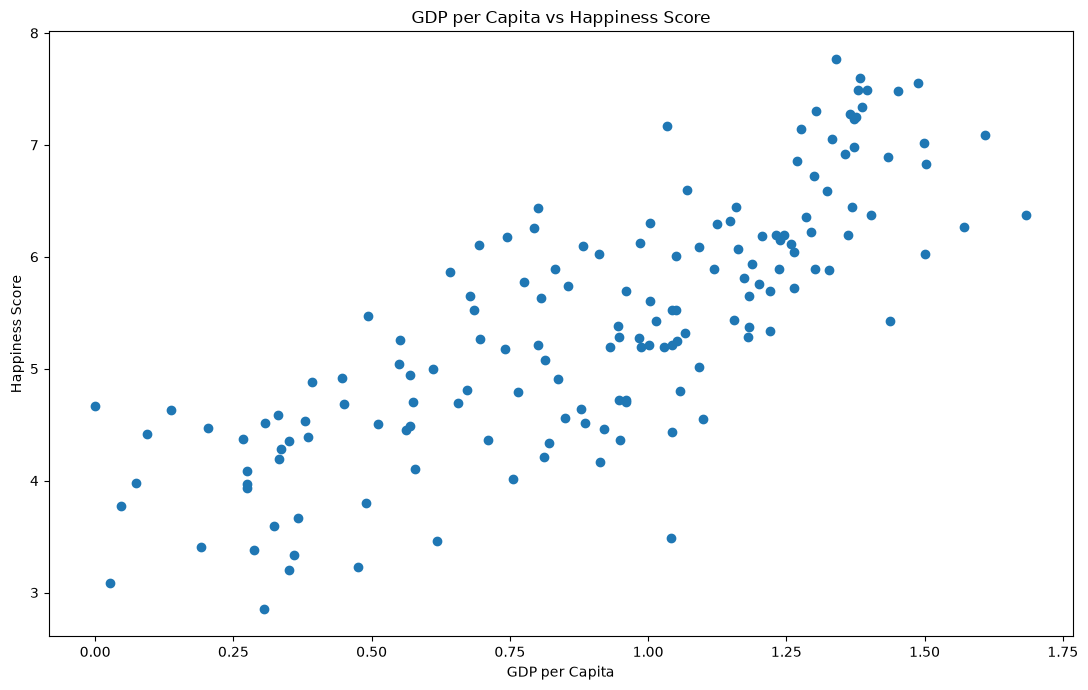

In [29]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    df["gdp_per_capita"],
    df["happiness_score"]
)

ax.set_title("GDP per Capita vs Happiness Score")
ax.set_xlabel("GDP per Capita")
ax.set_ylabel("Happiness Score")

plt.tight_layout()
plt.show()

In [31]:
df.nlargest(3, "gdp_per_capita")[[
    "country",
    "gdp_per_capita",
    "happiness_score"
]]

,country,gdp_per_capita,happiness_score
28,Qatar,1.684,6.374
13,Luxembourg,1.609,7.090
33,Singapore,1.572,6.262


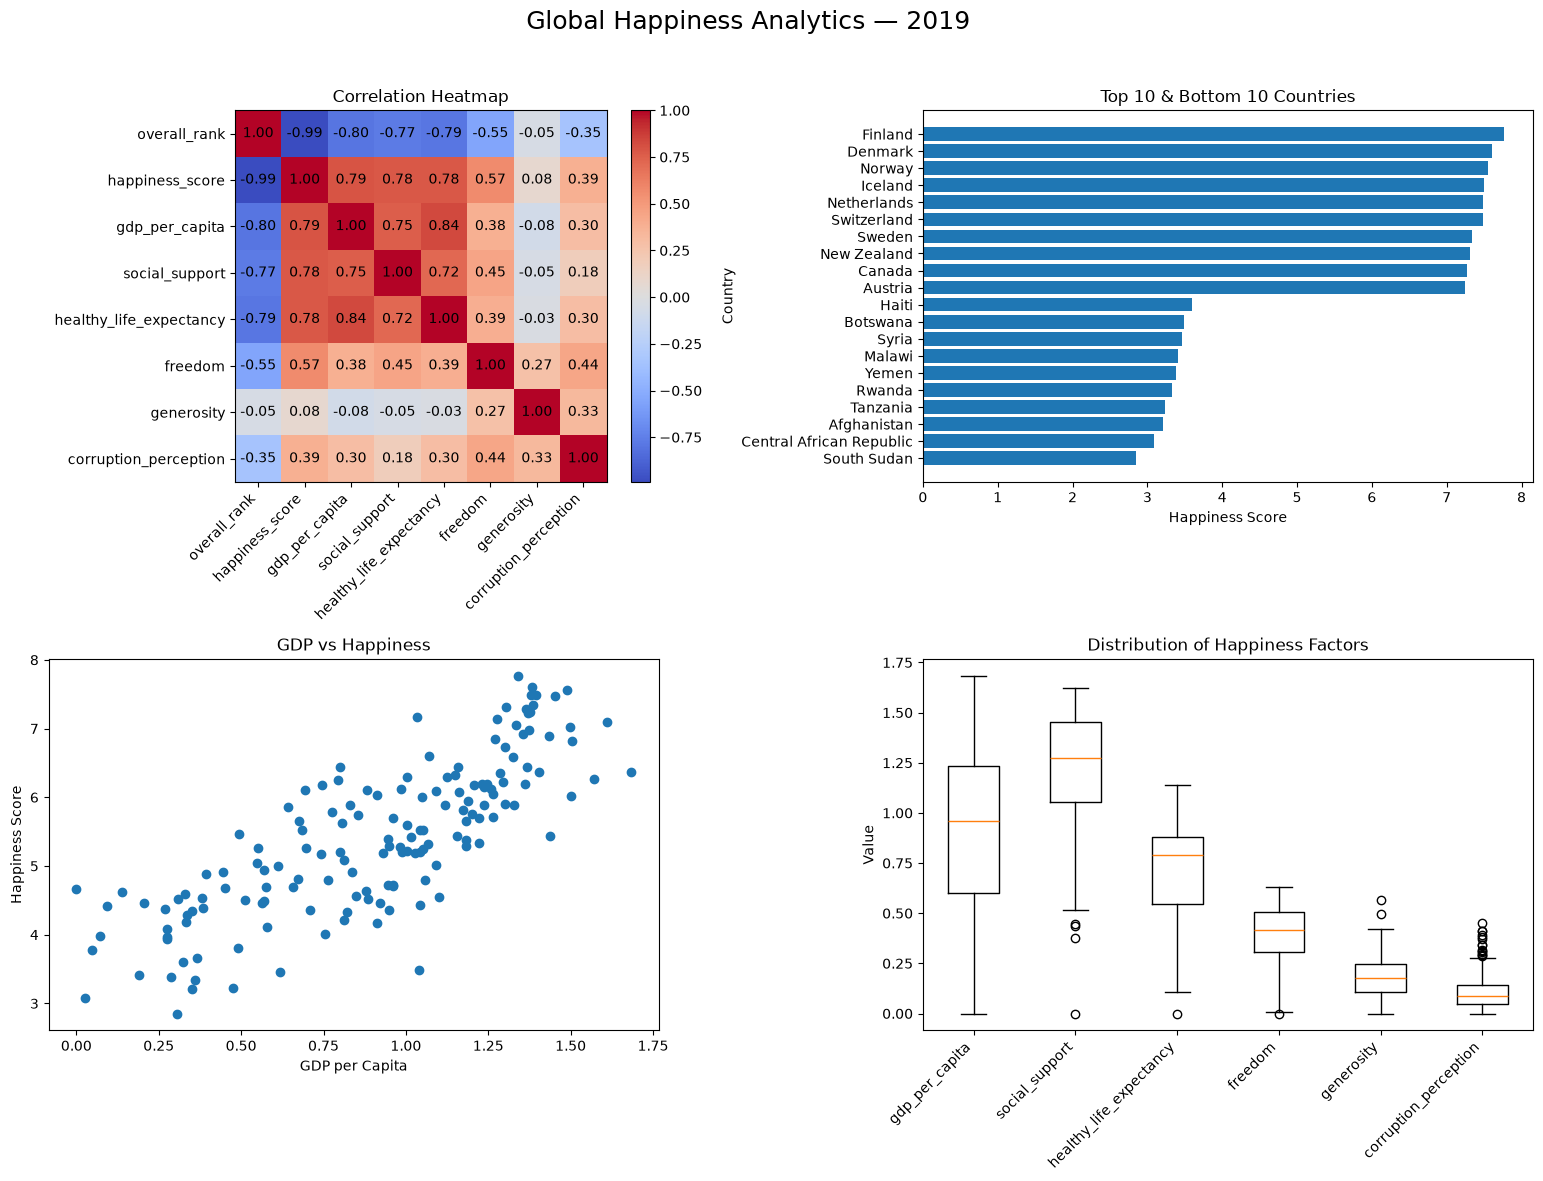

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# -----------------------------
# 1. Correlation Heatmap
# -----------------------------

ax = axes[0, 0]

im = ax.imshow(correlation_matrix, cmap="coolwarm")

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(correlation_matrix.columns)

ax.set_title("Correlation Heatmap")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )


# -----------------------------
# 2. Ranking Chart
# -----------------------------

ax = axes[0, 1]

ax.barh(
    ranking_df["country"],
    ranking_df["happiness_score"]
)

ax.set_title("Top 10 & Bottom 10 Countries")
ax.set_xlabel("Happiness Score")
ax.set_ylabel("Country")


# -----------------------------
# 3. GDP vs Happiness
# -----------------------------

ax = axes[1, 0]

ax.scatter(
    df["gdp_per_capita"],
    df["happiness_score"]
)

ax.set_title("GDP vs Happiness")
ax.set_xlabel("GDP per Capita")
ax.set_ylabel("Happiness Score")


# -----------------------------
# 4. Feature Distributions
# -----------------------------

ax = axes[1, 1]

ax.boxplot(
    [df[feature].dropna() for feature in features],
    tick_labels=features
)

ax.set_title("Distribution of Happiness Factors")
ax.set_ylabel("Value")

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

# Shared title
fig.suptitle(
    "Global Happiness Analytics — 2019",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "final_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()